# TABLE - Chuẩn hóa dữ liệu bảng có kiểm định và trực quan hóa

# Mục lục

* [1. Các phương pháp chuẩn hóa](#sec-1)
    * [1.1 Min-Max Scaling](#sec-1-1)
    * [1.2 Z-score Standardization](#sec-1-2)
    * [1.3 Robust Scaling](#sec-1-3)
    * [1.4 Quantile Transform](#sec-1-4)
        * [1.4.1. Output phân phối Uniform](#sec-1-4-1)
        * [1.4.2. Output phân phối Normal](#sec-1-4-2)
* [2. Bảng so sánh các phương pháp chuẩn hóa](#sec-2)
* [3. Kiểm định Levene (Levene's Test)](#sec-3)
    * [3.1 Lý thuyết kiểm định và giả định](#sec-3-1)
    * [3.2 Tại sao cần kiểm tra đồng nhất phương sai?](#sec-3-2)
    * [3.3 Ưu điểm](#sec-3-3)
    * [3.4 Hạn chế](#sec-3-4)
    * [3.5 Phù hợp cho bộ dữ liệu như nào?](#sec-3-5)
* [4. Thực hành áp dụng các phương pháp scaling và kiểm định Levene](#sec-4)
* [5. Nhận xét và phân tích](#sec-5)
    * [5.1 Tổng quan kết quả Levene theo từng cột](#sec-5-1)
    * [5.2 Vì sao nhiều cột bị bác bỏ $H_0$?](#sec-5-2)
    * [5.3 Vì sao một số cột không bị bác bỏ ở Robust?](#sec-5-3)
    * [5.4 Kết quả có phản ánh đặc trưng dữ liệu không?](#sec-5-4)
    * [5.5 Rút ra từ bộ dữ liệu này](#sec-5-5)
* [6. Trực quan phân phối bằng Violin Plot](#sec-6)
    * [6.1 Nhận xét biểu đồ Violin Plot](#sec-6-1)


<a id="sec-1"></a>

# 1. Các phương pháp chuẩn hóa

Chuẩn hóa (normalization/scaling) là bước biến đổi dữ liệu số về cùng thang đo để:
- Giảm hiện tượng đặc trưng có độ lớn quá chênh lệch nhau.
- Giúp mô hình học máy hội tụ nhanh hơn.
- Làm cho khoảng cách/tối ưu hóa ổn định hơn (đặc biệt với các mô hình dựa trên khoảng cách và gradient).

<a id="sec-1-1"></a>

## 1.1 Min-Max Scaling

### Nguyên lí
Biến đổi dữ liệu tuyến tính từ miền giá trị gốc về một khoảng cố định, phổ biến là $[0,1]$.

### Công thức
Với khoảng đích $[0,1]$:
$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

Tổng quát với khoảng đích $[a,b]$:
$$
x' = a + \frac{(x - x_{\min})(b-a)}{x_{\max} - x_{\min}}
$$

### Ưu điểm
- Dễ hiểu, dễ triển khai.
- Giữ được thứ tự tương đối giữa các điểm dữ liệu.
- Hữu ích khi thuật toán cần dữ liệu trong khoảng hữu hạn (ví dụ mạng nơ-ron với một số hàm kích hoạt).

### Hạn chế
- Rất nhạy với outlier: chỉ một giá trị cực trị có thể làm phần lớn dữ liệu bị nén.
- Khi dữ liệu mới vượt ngoài $[x_{\min}, x_{\max}]$ của tập huấn luyện, giá trị biến đổi có thể ra ngoài khoảng mong muốn.

<a id="sec-1-2"></a>

## 1.2 Z-score Standardization

### Nguyên lí
Đưa dữ liệu về dạng có trung bình gần 0 và độ lệch chuẩn gần 1.

### Công thức
$$
z = \frac{x - \mu}{\sigma}
$$
Trong đó:
- $\mu$: trung bình của đặc trưng trên tập huấn luyện.
- $\sigma$: độ lệch chuẩn của đặc trưng trên tập huấn luyện.

### Ưu điểm
- Phù hợp với nhiều thuật toán tuyến tính, SVM, Logistic Regression, PCA.
- Không ép dữ liệu vào khoảng cố định, nên vẫn phản ánh mức độ "xa trung bình".
- Thường hoạt động tốt khi phân phối dữ liệu gần chuẩn.

### Hạn chế
- Nhạy với outlier do $\mu$ và $\sigma$ bị ảnh hưởng mạnh bởi giá trị cực trị.
- Nếu dữ liệu lệch mạnh (skewed), hiệu quả chuẩn hóa có thể không tối ưu.

<a id="sec-1-3"></a>

## 1.3 Robust Scaling

### Nguyên lí
Chuẩn hóa bằng trung vị và khoảng tứ phân vị để giảm ảnh hưởng của outlier.

### Công thức
$$
x' = \frac{x - Q_2}{IQR}, \quad IQR = Q_3 - Q_1
$$
Trong đó:
- $Q_2$: trung vị (median).
- $Q_1, Q_3$: tứ phân vị thứ nhất và thứ ba.

### Ưu điểm
- Bền vững trước outlier hơn Min-Max và Z-score.
- Thích hợp cho dữ liệu có phân phối lệch hoặc chứa nhiều nhiễu.

### Hạn chế
- Không đưa dữ liệu về khoảng cố định.
- Nếu dữ liệu có rất nhiều giá trị trùng nhau quanh median, việc scale có thể kém phân tách.

<a id="sec-1-4"></a>

## 1.4 Quantile Transform

### Nguyên lí
Dựa trên phân phối tích lũy thực nghiệm (ECDF), ánh xạ dữ liệu gốc sang một phân phối mục tiêu.

Bước chung:
1. Tính bách phân vị của mỗi giá trị: $u = \hat{F}(x)$ với $u \in (0,1)$.
2. Ánh xạ $u$ sang phân phối đầu ra mong muốn.

<a id="sec-1-4-1"></a>

### 1.4.1. Output phân phối Uniform
#### Công thức
$$
x' = u = \hat{F}(x)
$$
Kết quả nằm gần trong khoảng $[0,1]$ và có dạng gần đều.

#### Ưu điểm
- Giảm ảnh hưởng của outlier rất mạnh.
- Đưa dữ liệu về cùng một phân phối rõ ràng, thuận lợi cho một số mô hình.

#### Hạn chế
- Biến đổi phi tuyến nên có thể làm thay đổi khoảng cách gốc giữa các điểm dữ liệu.
- Có thể làm mất ý nghĩa tỉ lệ ban đầu của đặc trưng.

<a id="sec-1-4-2"></a>

### 1.4.2. Output phân phối Normal
#### Công thức
$$
x' = \Phi^{-1}(u) = \Phi^{-1}(\hat{F}(x))
$$
Trong đó $\Phi^{-1}$ là hàm nghịch đảo CDF của phân phối chuẩn tắc.

#### Ưu điểm
- Tạo đặc trưng gần phân phối chuẩn, hữu ích cho các phương pháp giả định Gaussian.
- Giảm ảnh hưởng outlier tốt hơn Z-score trong nhiều trường hợp lệch mạnh.

#### Hạn chế
- Cũng là biến đổi phi tuyến, có thể làm méo quan hệ tuyến tính ban đầu.
- Với dữ liệu mới ngoài miền quan sát, phép ánh xạ có thể bão hòa ở hai đầu phân phối.


<a id="sec-2"></a>

# 2. Bảng so sánh các phương pháp chuẩn hóa

| Phương pháp | Nguyên lí | Độ phức tạp (fit/transform) | Giả định chính | Phù hợp dữ liệu | Công thức tính |
|---|---|---|---|---|---|
| **Min-Max Scaling** | Co giãn tuyến tính dữ liệu về khoảng cố định (thường $[0,1]$). | Thấp: fit $O(n)$, transform $O(n)$ cho mỗi đặc trưng. | Giá trị min/max trong train đại diện tốt cho dữ liệu thực tế; ít outlier mạnh. | Dữ liệu sạch, ít ngoại lệ, cần giá trị trong khoảng hữu hạn. | $x' = \frac{x-x_{\min}}{x_{\max}-x_{\min}}$ (hoặc tổng quát về $[a,b]$). |
| **Z-score Standardization** | Tịnh tiến theo trung bình và co giãn theo độ lệch chuẩn để dữ liệu có mean 0, std 1. | Thấp: fit $O(n)$, transform $O(n)$. | Phân phối không quá lệch; outlier không quá cực đoan. | Mô hình tuyến tính, SVM, PCA, Logistic Regression. | $z = \frac{x-\mu}{\sigma}$ |
| **Robust Scaling** | Chuẩn hóa bằng median và IQR để giảm tác động outlier. | Thấp-trung bình: fit $O(n\log n)$ (cần quantile), transform $O(n)$. | Median và IQR mô tả tốt trung tâm và độ phân tán của dữ liệu. | Dữ liệu có nhiều outlier hoặc lệch phân phối. | $x' = \frac{x-Q_2}{Q_3-Q_1}$ |
| **Quantile Transform (Uniform output)** | Ánh xạ theo ECDF về phân phối đều trong $[0,1]$. | Trung bình-cao: fit cần sắp xếp/ước lượng quantile ($O(n\log n)$), transform nội suy theo quantile. | Thứ hạng (rank) quan trọng hơn khoảng cách tuyệt đối; chấp nhận biến đổi phi tuyến. | Dữ liệu lệch mạnh, nhiều outlier; cần phân phối đầu ra đồng đều. | $u=\hat{F}(x),\; x'=u$ |
| **Quantile Transform (Normal output)** | Dùng ECDF lấy $u$, sau đó chiếu qua nghịch đảo CDF chuẩn để về gần Gaussian. | Trung bình-cao: tương tự quantile uniform + phép biến đổi $\Phi^{-1}$. | Muốn dữ liệu gần chuẩn; chấp nhận mất quan hệ tuyến tính gốc. | Dữ liệu lệch mạnh, mô hình hưởng lợi khi đầu vào gần chuẩn. | $u=\hat{F}(x),\; x' = \Phi^{-1}(u)$ |

**Ghi chú:**
- $n$ là số mẫu trên một đặc trưng.
- Với dữ liệu mới (test/inference), luôn dùng tham số đã fit từ tập train để tránh rò rỉ dữ liệu.

<a id="sec-3"></a>

# 3. Kiểm định Levene (Levene's Test)

<a id="sec-3-1"></a>

## 3.1 Lý thuyết kiểm định và giả định
Levene's test được dùng để kiểm tra **đồng nhất phương sai** (homogeneity of variances) giữa nhiều nhóm dữ liệu.

- **Giả thuyết $H_0$:**
$$
\sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2
$$
- **Giả thuyết $H_1$:**
$$
\exists\ i,j:\ \sigma_i^2 \ne \sigma_j^2
$$

Ý tưởng chính của Levene:
1. Với mỗi quan sát $x_{ij}$ trong nhóm $i$, tính độ lệch tuyệt đối so với trung tâm nhóm:
$$
z_{ij} = |x_{ij} - c_i|
$$
Trong đó $c_i$ có thể là **mean**, **median** (phổ biến, bền vững hơn với outlier) hoặc **trimmed mean**.

2. Sau đó thực hiện ANOVA một yếu tố trên các giá trị $z_{ij}$.

3. Nếu p-value nhỏ hơn mức ý nghĩa $\alpha$, bác bỏ $H_0$ (phương sai giữa các nhóm không đồng nhất).

**Giả định quan trọng:**
- Các nhóm độc lập với nhau.
- Dữ liệu trong mỗi nhóm là số (numeric) và đo trên thang phù hợp để tính độ lệch.
- Levene không yêu cầu chuẩn nghiêm ngặt như Bartlett, nên thường dùng tốt hơn khi dữ liệu lệch chuẩn.

<a id="sec-3-2"></a>

## 3.2 Tại sao cần kiểm tra đồng nhất phương sai?
Nhiều kiểm định suy luận cổ điển giả định phương sai giữa các nhóm là tương đương (ví dụ ANOVA cổ điển, t-test phiên bản equal variance). Nếu bỏ qua bước này, kết luận thống kê có thể sai lệch.

**Hậu quả khi không thỏa điều kiện đồng nhất phương sai:**
- p-value của ANOVA/t-test có thể bị lệch, làm tăng nguy cơ kết luận sai.
- Tăng xác suất lỗi loại I (báo có khác biệt khi thực tế không có), đặc biệt khi cỡ mẫu các nhóm mất cân bằng.
- Giảm power trong một số bối cảnh, làm bỏ sót khác biệt thật.
- Khoảng tin cậy và độ lớn hiệu ứng có thể bị diễn giải sai.

Khi Levene cho thấy phương sai không đồng nhất, nên cân nhắc:
- Welch's t-test hoặc Welch's ANOVA.
- Dùng sai số chuẩn robust (heteroskedasticity-robust).
- Biến đổi dữ liệu (log, Box-Cox) nếu phù hợp ngữ cảnh.

<a id="sec-3-3"></a>

## 3.3 Ưu điểm
- Dễ hiểu, dễ triển khai, có sẵn trong hầu hết thư viện thống kê.
- Ít nhạy với vi phạm chuẩn hơn Bartlett test.
- Linh hoạt chọn tâm nhóm (mean/median/trimmed), trong đó median thường ổn định với outlier.
- Dùng được cho từ 2 nhóm trở lên.

<a id="sec-3-4"></a>

## 3.4 Hạn chế
- Vẫn bị ảnh hưởng nếu dữ liệu có quá nhiều outlier cực đoan hoặc cỡ mẫu rất nhỏ.
- Chỉ kiểm tra phương sai, không nói về khác biệt trung bình hay hình dạng phân phối.
- Kết quả nhạy với lựa chọn center (mean vs median vs trimmed).
- Với cỡ mẫu rất lớn, khác biệt phương sai nhỏ cũng có thể trở nên có ý nghĩa thống kê nhưng không có nhiều ý nghĩa thực tiễn.

<a id="sec-3-5"></a>

## 3.5 Phù hợp cho bộ dữ liệu như nào?
Levene đặc biệt phù hợp khi:
- So sánh nhiều nhóm có dữ liệu số liên tục/định lượng.
- Dữ liệu có khả năng lệch chuẩn hoặc có outlier vừa phải.
- Cần kiểm tra điều kiện trước khi chạy ANOVA/t-test hoặc các phân tích so sánh nhóm.

Ít phù hợp khi:
- Dữ liệu quá ít ở từng nhóm (khó có kết luận ổn định).
- Dữ liệu là biến phân loại/nhị phân thuần túy.
- Các quan sát không độc lập (ví dụ dữ liệu lặp theo thời gian nhưng không xử lý cấu trúc phụ thuộc).

<a id="sec-4"></a>

# 4. Thực hành áp dụng các phương pháp scaling và kiểm định Levene

Trong phần này, ta sẽ:
- Áp dụng lần lượt 5 phương pháp: Min-Max, Z-score, Robust, Quantile (uniform), Quantile (normal).
- Sau mỗi lần scaling, in ra các cột đã scale và 5 dòng đầu dữ liệu sau biến đổi.
- Áp dụng kiểm định Levene để so sánh phương sai giữa dữ liệu trước và sau scaling.

In [6]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from table.preprocessing_normalization import StatisticalNormalization, QuantileNormalization
from statistic.test_variance import LeveneTesting

In [7]:
data_path = PROJECT_ROOT / "data" / "table" / "Building_Permits.csv"
df_raw = pd.read_csv(data_path)

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if not numeric_cols:
    raise ValueError("Không tìm thấy cột số để scaling.")

X_numeric = df_raw[numeric_cols].copy()
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)
X_numeric = X_numeric.fillna(X_numeric.median(numeric_only=True))

MAX_ROWS = 20000
if len(X_numeric) > MAX_ROWS:
    X_numeric = X_numeric.sample(n=MAX_ROWS, random_state=42).sort_index()

print(f"Số dòng sử dụng để scaling: {len(X_numeric)}")
print(f"Số cột số được scaling: {len(numeric_cols)}")
print("Danh sách cột số:")
print(numeric_cols)

display(X_numeric.head())

C:\Users\hoang\AppData\Local\Temp\ipykernel_19480\213701034.py:2: DtypeWarning: Columns (0: Voluntary Soft-Story Retrofit, 1: TIDF Compliance) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(data_path)


Số dòng sử dụng để scaling: 20000
Số cột số được scaling: 15
Danh sách cột số:
['Permit Type', 'Street Number', 'Unit', 'Number of Existing Stories', 'Number of Proposed Stories', 'Estimated Cost', 'Revised Cost', 'Existing Units', 'Proposed Units', 'Plansets', 'Existing Construction Type', 'Proposed Construction Type', 'Supervisor District', 'Zipcode', 'Record ID']


,Permit Type,Street Number,Unit,Number of Existing Stories,Number of Proposed Stories,Estimated Cost,Revised Cost,Existing Units,Proposed Units,Plansets,Existing Construction Type,Proposed Construction Type,Supervisor District,Zipcode,Record ID
4,6,950,0.0,3.0,3.0,100000.0,100000.0,1.0,2.0,2.0,3.0,5.0,6.0,94102.0,144548169992
6,8,1291,0.0,3.0,3.0,12000.0,12000.0,5.0,5.0,0.0,5.0,5.0,5.0,94122.0,1468970403692
12,8,4082,0.0,3.0,3.0,11000.0,1.0,1.0,2.0,2.0,5.0,5.0,8.0,94114.0,1469781206718
22,3,2150,0.0,3.0,3.0,100000.0,7000.0,6.0,6.0,2.0,5.0,5.0,3.0,94133.0,147281357792
33,3,76,0.0,3.0,3.0,73000.0,73000.0,6.0,6.0,2.0,5.0,5.0,6.0,94105.0,1476032285416


In [8]:
def run_scaling_and_levene(method_name, scaler, X, alpha=0.05):
    print("\n" + "=" * 80)
    print(f"Phương pháp: {method_name}")

    X_scaled = scaler.fit_transform(X)
    if not isinstance(X_scaled, pd.DataFrame):
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

    print(f"Số cột đã scaling: {len(X_scaled.columns)}")
    print("Tên các cột đã scaling:")
    print(list(X_scaled.columns))

    print("Giá trị 5 dòng đầu sau scaling:")
    display(X_scaled.head())

    # Chỉ kiểm định Levene theo từng cột, chọn median làm center
    tester = LeveneTesting(alpha=alpha, center="median")
    per_col_rows = []

    for col in X.columns:
        x_before = X[col].to_numpy(dtype=float)
        x_after = X_scaled[col].to_numpy(dtype=float)

        stat_col, p_col = tester.test(x_before, x_after)
        decision = "Bác bỏ H0" if p_col <= alpha else "Chưa bác bỏ H0"

        var_before = float(np.var(x_before, ddof=1))
        var_after = float(np.var(x_after, ddof=1))
        ratio = (var_after / var_before) if var_before != 0 else np.nan

        per_col_rows.append(
            {
                "Cột": col,
                "Thống kê Levene": stat_col,
                "p-value": p_col,
                "Phương sai trước": var_before,
                "Phương sai sau": var_after,
                "Tỷ số phương sai (sau/trước)": ratio,
                "Quyết định": decision,
            }
        )

    per_col_df = pd.DataFrame(per_col_rows).sort_values(by="p-value", ascending=True, na_position="last")
    n_reject = int((per_col_df["p-value"] <= alpha).sum())
    total_cols = len(per_col_df)
    reject_rate = round((n_reject / total_cols) * 100, 2) if total_cols else 0.0

    print(f"\nKết quả Levene theo từng cột: Bác bỏ H0 ở {n_reject}/{total_cols} cột ({reject_rate}%)")
    print("Top 10 cột có p-value nhỏ nhất:")
    display(per_col_df.head(10))

    summary_row = {
        "Phương pháp": method_name,
        "Số cột bác bỏ H0": n_reject,
        "Tổng số cột": total_cols,
        "Tỷ lệ bác bỏ (%)": reject_rate,
        "p-value nhỏ nhất": float(per_col_df["p-value"].min()),
        "p-value trung vị": float(per_col_df["p-value"].median()),
    }

    return X_scaled, summary_row, per_col_df

In [9]:
scalers = {
    "Chuẩn hóa Min-Max": StatisticalNormalization(method="minmax"),
    "Chuẩn hóa Z-score": StatisticalNormalization(method="zscore"),
    "Chuẩn hóa Robust": StatisticalNormalization(method="robust"),
    "Quantile Transform (uniform)": QuantileNormalization(
        output_distribution="uniform",
        random_state=42,
    ),
    "Quantile Transform (normal)": QuantileNormalization(
        output_distribution="normal",
        random_state=42,
    ),
}

scaled_results = {}
summary_rows = []
levene_by_column = {}

for method_name, scaler in scalers.items():
    scaled_df, summary_row, per_col_df = run_scaling_and_levene(method_name, scaler, X_numeric)
    scaled_results[method_name] = scaled_df
    summary_rows.append(summary_row)
    levene_by_column[method_name] = per_col_df

summary_df = pd.DataFrame(summary_rows)
print("\nTổng hợp kết quả Levene theo từng cột cho tất cả phương pháp:")
display(summary_df)


Phương pháp: Chuẩn hóa Min-Max
Số cột đã scaling: 15
Tên các cột đã scaling:
['Permit Type', 'Street Number', 'Unit', 'Number of Existing Stories', 'Number of Proposed Stories', 'Estimated Cost', 'Revised Cost', 'Existing Units', 'Proposed Units', 'Plansets', 'Existing Construction Type', 'Proposed Construction Type', 'Supervisor District', 'Zipcode', 'Record ID']
Giá trị 5 dòng đầu sau scaling:


,Permit Type,Street Number,Unit,Number of Existing Stories,Number of Proposed Stories,Estimated Cost,Revised Cost,Existing Units,Proposed Units,Plansets,Existing Construction Type,Proposed Construction Type,Supervisor District,Zipcode,Record ID
4,0.714286,0.114008,0.0,0.047619,0.047619,0.000926,9.259259e-04,0.000524,0.001049,0.666667,0.5,1.0,0.5,0.000000,0.088587
6,1.000000,0.154974,0.0,0.047619,0.047619,0.000111,1.111111e-04,0.002622,0.002622,0.000000,1.0,1.0,0.4,0.357143,0.980230
12,1.000000,0.490269,0.0,0.047619,0.047619,0.000102,9.259259e-09,0.000524,0.001049,0.666667,1.0,1.0,0.7,0.214286,0.980776
22,0.285714,0.258169,0.0,0.047619,0.047619,0.000926,6.481481e-05,0.003146,0.003146,0.666667,1.0,1.0,0.2,0.553571,0.090427
33,0.285714,0.009010,0.0,0.047619,0.047619,0.000676,6.759259e-04,0.003146,0.003146,0.666667,1.0,1.0,0.5,0.053571,0.984984



Kết quả Levene theo từng cột: Bác bỏ H0 ở 15/15 cột (100.0%)
Top 10 cột có p-value nhỏ nhất:


,Cột,Thống kê Levene,p-value,Phương sai trước,Phương sai sau,Tỷ số phương sai (sau/trước),Quyết định
0,Permit Type,1559.070551,0.0,2.163652e+00,0.044156,2.040816e-02,Bác bỏ H0
1,Street Number,18774.365622,0.0,1.325574e+06,0.019131,1.443231e-08,Bác bỏ H0
3,Number of Existing Stories,2868.016010,0.0,6.335298e+01,0.015962,2.519526e-04,Bác bỏ H0
4,Number of Proposed Stories,2831.196150,0.0,6.286593e+01,0.015839,2.519526e-04,Bác bỏ H0
12,Supervisor District,41819.728529,0.0,8.292539e+00,0.082925,1.000000e-02,Bác bỏ H0
11,Proposed Construction Type,2599.132354,0.0,2.105388e+00,0.131587,6.250000e-02,Bác bỏ H0
10,Existing Construction Type,2658.594394,0.0,2.123514e+00,0.132720,6.250000e-02,Bác bỏ H0
9,Plansets,3713.495325,0.0,8.678262e-01,0.096425,1.111111e-01,Bác bỏ H0
14,Record ID,7264.972667,0.0,2.480164e+23,0.112411,4.532409e-25,Bác bỏ H0
13,Zipcode,28985.790135,0.0,8.562889e+01,0.027305,3.188776e-04,Bác bỏ H0



Phương pháp: Chuẩn hóa Z-score
Số cột đã scaling: 15
Tên các cột đã scaling:
['Permit Type', 'Street Number', 'Unit', 'Number of Existing Stories', 'Number of Proposed Stories', 'Estimated Cost', 'Revised Cost', 'Existing Units', 'Proposed Units', 'Plansets', 'Existing Construction Type', 'Proposed Construction Type', 'Supervisor District', 'Zipcode', 'Record ID']
Giá trị 5 dòng đầu sau scaling:


...

,Permit Type,Street Number,Unit,Number of Existing Stories,Number of Proposed Stories,Estimated Cost,Revised Cost,Existing Units,Proposed Units,Plansets,Existing Construction Type,Proposed Construction Type,Supervisor District,Zipcode,Record ID
4,-1.298271,0.205941,-5.199338,0.082896,0.05146,1.331018,1.292465,-0.263985,0.149853,0.404717,-0.886449,5.199338,0.120731,-5.199338,-1.059172
6,5.199338,0.406419,-5.199338,0.082896,0.05146,0.262686,0.271787,0.961429,0.941700,-5.199338,5.199338,5.199338,-0.162552,0.708752,1.180340
12,5.199338,1.996815,-5.199338,0.082896,0.05146,-0.016310,-0.995858,-0.263985,0.149853,0.404717,5.199338,5.199338,0.692715,-0.064027,1.199232
22,-1.700222,0.907937,-5.199338,0.082896,0.05146,1.331018,-0.012546,1.046576,1.020888,0.404717,5.199338,5.199338,-0.610484,1.767903,-0.957403
33,-1.700222,-1.228607,-5.199338,0.082896,0.05146,1.161155,1.122724,1.046576,1.020888,0.404717,5.199338,5.199338,0.120731,-1.102440,1.343926



Kết quả Levene theo từng cột: Bác bỏ H0 ở 15/15 cột (100.0%)
Top 10 cột có p-value nhỏ nhất:


,Cột,Thống kê Levene,p-value,Phương sai trước,Phương sai sau,Tỷ số phương sai (sau/trước),Quyết định
1,Street Number,18742.225826,0.000000e+00,1.325574e+06,1.262372,9.523209e-07,Bác bỏ H0
3,Number of Existing Stories,1767.089651,0.000000e+00,6.335298e+01,0.947240,1.495179e-02,Bác bỏ H0
4,Number of Proposed Stories,1752.438032,0.000000e+00,6.286593e+01,0.903263,1.436808e-02,Bác bỏ H0
14,Record ID,7264.972667,0.000000e+00,2.480164e+23,1.001977,4.039963e-24,Bác bỏ H0
12,Supervisor District,8533.558455,0.000000e+00,8.292539e+00,3.248298,3.917134e-01,Bác bỏ H0
11,Proposed Construction Type,1668.207673,0.000000e+00,2.105388e+00,14.262489,6.774280e+00,Bác bỏ H0
10,Existing Construction Type,1702.882165,0.000000e+00,2.123514e+00,14.362270,6.763445e+00,Bác bỏ H0
9,Plansets,3417.974481,0.000000e+00,8.678262e-01,6.845763,7.888403e+00,Bác bỏ H0
13,Zipcode,22315.935397,0.000000e+00,8.562889e+01,1.872030,2.186213e-02,Bác bỏ H0
8,Proposed Units,586.318806,1.339419e-128,3.780562e+03,4.015236,1.062074e-03,Bác bỏ H0



Tổng hợp kết quả Levene theo từng cột cho tất cả phương pháp:


,Phương pháp,Số cột bác bỏ H0,Tổng số cột,Tỷ lệ bác bỏ (%),p-value nhỏ nhất,p-value trung vị
0,Chuẩn hóa Min-Max,15,15,100.0,0.0,0.000000e+00
1,Chuẩn hóa Z-score,15,15,100.0,0.0,1.020305e-143
2,Chuẩn hóa Robust,9,15,60.0,0.0,1.418107e-22
3,Quantile Transform (uniform),15,15,100.0,0.0,0.000000e+00
4,Quantile Transform (normal),15,15,100.0,0.0,0.000000e+00


<a id="sec-5"></a>

# 5. Nhận xét và phân tích

<a id="sec-5-1"></a>

## 5.1 Tổng quan kết quả Levene theo từng cột
Từ kết quả kiểm định theo cột , ta có:
- **Chuẩn hóa Min-Max**: bác bỏ $H_0$ ở **15/15 cột**.
- **Chuẩn hóa Z-score**: bác bỏ $H_0$ ở **15/15 cột**.
- **Chuẩn hóa Robust**: bác bỏ $H_0$ ở **9/15 cột**, không bác bỏ ở **6/15 cột**.
- **Quantile Transform (uniform)**: bác bỏ $H_0$ ở **15/15 cột**.
- **Quantile Transform (normal)**: bác bỏ $H_0$ ở **15/15 cột**.

=> Nhìn chung, đa số phương pháp làm thay đổi phương sai rõ rệt; riêng Robust giữ ổn định hơn trên một số cột.

<a id="sec-5-2"></a>

## 5.2 Vì sao nhiều cột bị bác bỏ $H_0$?
Levene kiểm định giả thuyết:
$$
H_0: \sigma^2_{before} = \sigma^2_{after}
$$
Trong khi đó, scaling về bản chất thường **làm đổi phương sai**:
- Min-Max co dữ liệu về một khoảng hẹp (thường $[0,1]$), nên phương sai giảm mạnh.
- Z-score đưa dữ liệu về độ lệch chuẩn xấp xỉ 1, nên phương sai sau biến đổi gần 1.
- Quantile Transform là biến đổi phi tuyến theo phân vị, có thể đổi mạnh cả hình dạng phân phối và phương sai.

Ngoài ra, bộ dữ liệu đang dùng khoảng 20,000 dòng nên kiểm định có power lớn: khác biệt nhỏ cũng dễ cho p-value rất thấp.

<a id="sec-5-3"></a>

## 5.3 Vì sao một số cột **không** bị bác bỏ ở Robust?
Các cột không bác bỏ $H_0$ với Robust gồm:
- `Permit Type`
- `Unit`
- `Number of Existing Stories`
- `Existing Units`
- `Existing Construction Type`
- `Proposed Construction Type`

Phân tích:
- Robust scaling dùng công thức $x' = (x - \text{median})/IQR$.
- Ở các cột trên, kết quả cho thấy tỷ số phương sai (sau/trước) gần 1, tức biến đổi gần như không làm đổi độ phân tán.
- Nguyên nhân thường gặp là dữ liệu có nhiều giá trị lặp, miền giá trị hẹp, hoặc cấu trúc rời rạc (mã loại, số đếm), khiến phép chuẩn hóa robust gần với phép dịch/chia đơn giản và không phá phương sai nhiều.

<a id="sec-5-4"></a>

## 5.4 Kết quả có phản ánh đặc trưng dữ liệu không?
**Có.** Mẫu hình bác bỏ/không bác bỏ phản ánh khá rõ đặc trưng dữ liệu:
- Bộ dữ liệu chứa cả biến liên tục biên độ lớn (`Estimated Cost`, `Revised Cost`, `Street Number`, `Record ID`) và biến dạng mã/số đếm.
- Các cột biên độ rất lớn hoặc lệch phân phối mạnh bị tác động rõ hơn bởi scaling.
- Các cột rời rạc, ít mức giá trị có thể ổn định hơn dưới Robust.

Nghĩa là kết quả không chỉ do kiểm định, mà do **bản chất dữ liệu + cơ chế của từng scaler**.

<a id="sec-5-5"></a>

## 5.5 Rút ra từ bộ dữ liệu này
- Không nên áp cùng một kiểu scaling cho mọi cột mà không phân nhóm đặc trưng.
- Nên tách cột kiểu mã định danh/mã loại (ví dụ cột ID hoặc mã danh mục) khỏi cột liên tục thật sự trước khi scale.
- Với dữ liệu có outlier hoặc lệch mạnh, Robust/Quantile thường phù hợp hơn Min-Max cho cột liên tục.
- Levene theo từng cột là công cụ kiểm tra hậu kiểm tốt để thấy cột nào bị thay đổi phương sai nhiều sau preprocessing.

**Kết luận thực tiễn:**
Bộ dữ liệu này có tính không đồng nhất cao giữa các đặc trưng; do đó chiến lược tiền xử lý hợp lý là sử dụng đúng **scaling theo nhóm cột**, không nên xử lý đồng loạt một cách cơ học.

<a id="sec-6"></a>

# 6. Trực quan phân phối bằng Violin Plot

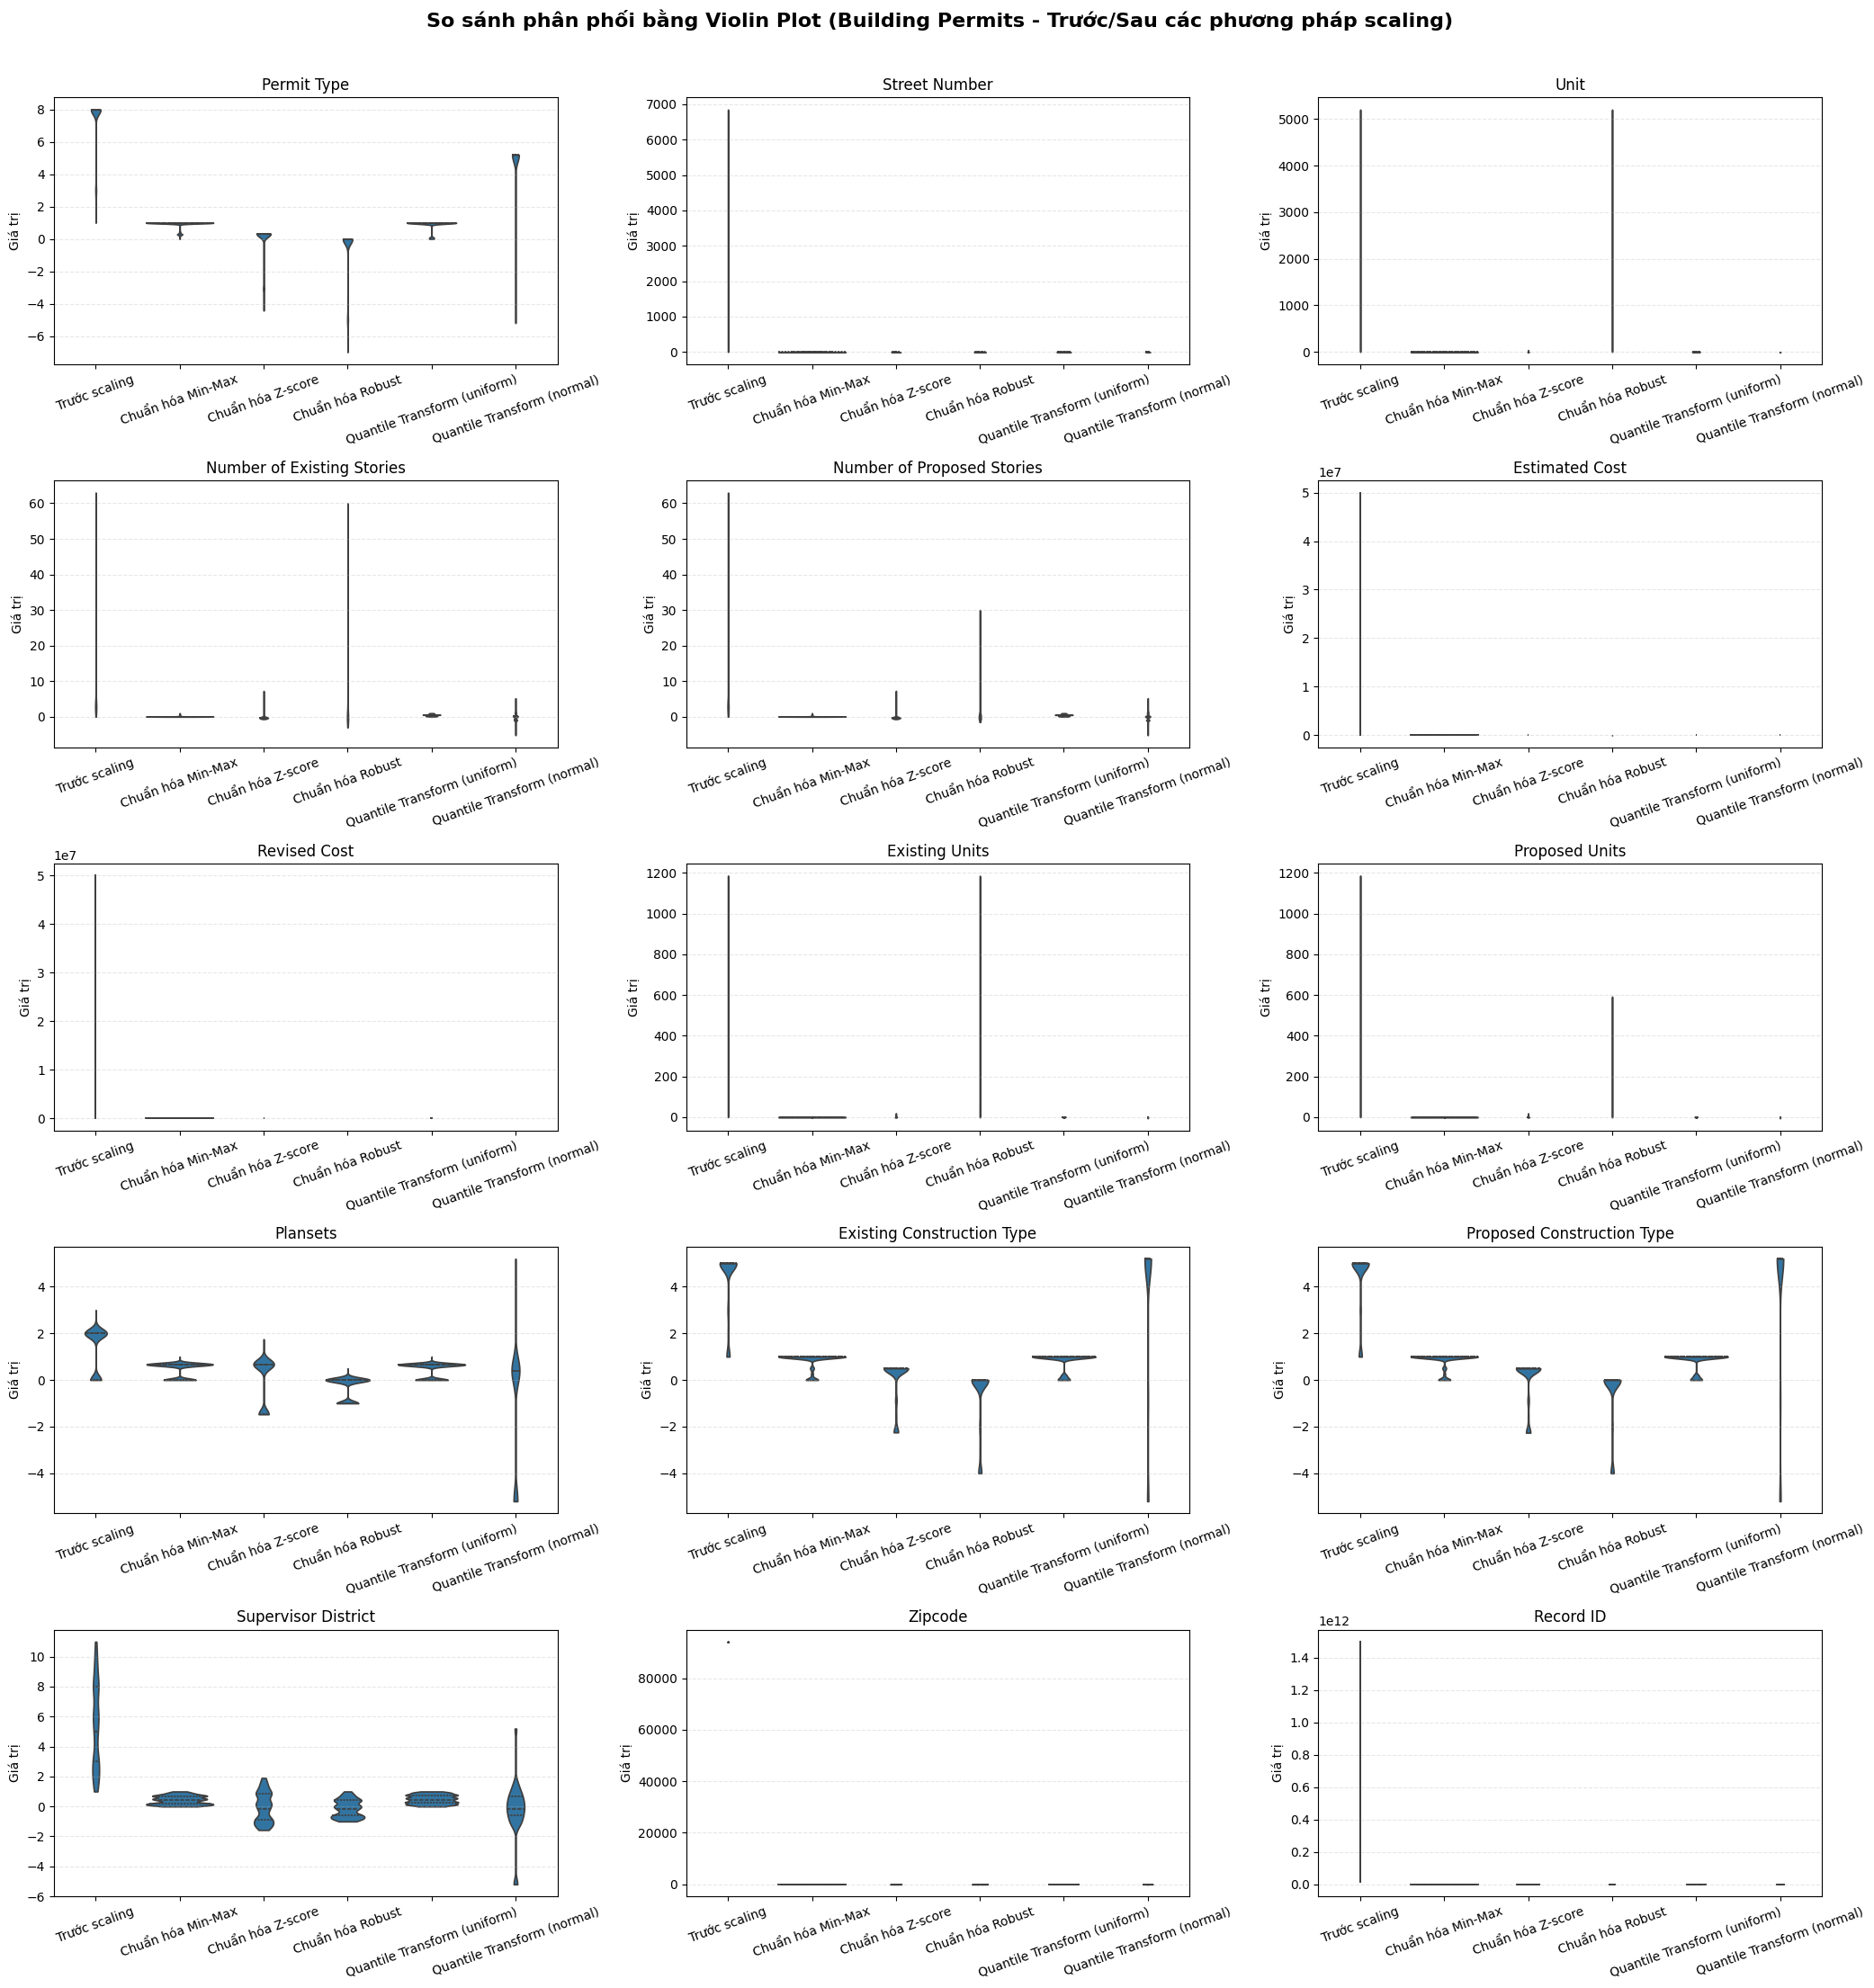

Các cột không bác bỏ H0 dưới Robust: ['Permit Type', 'Unit', 'Number of Existing Stories', 'Existing Units', 'Existing Construction Type', 'Proposed Construction Type']


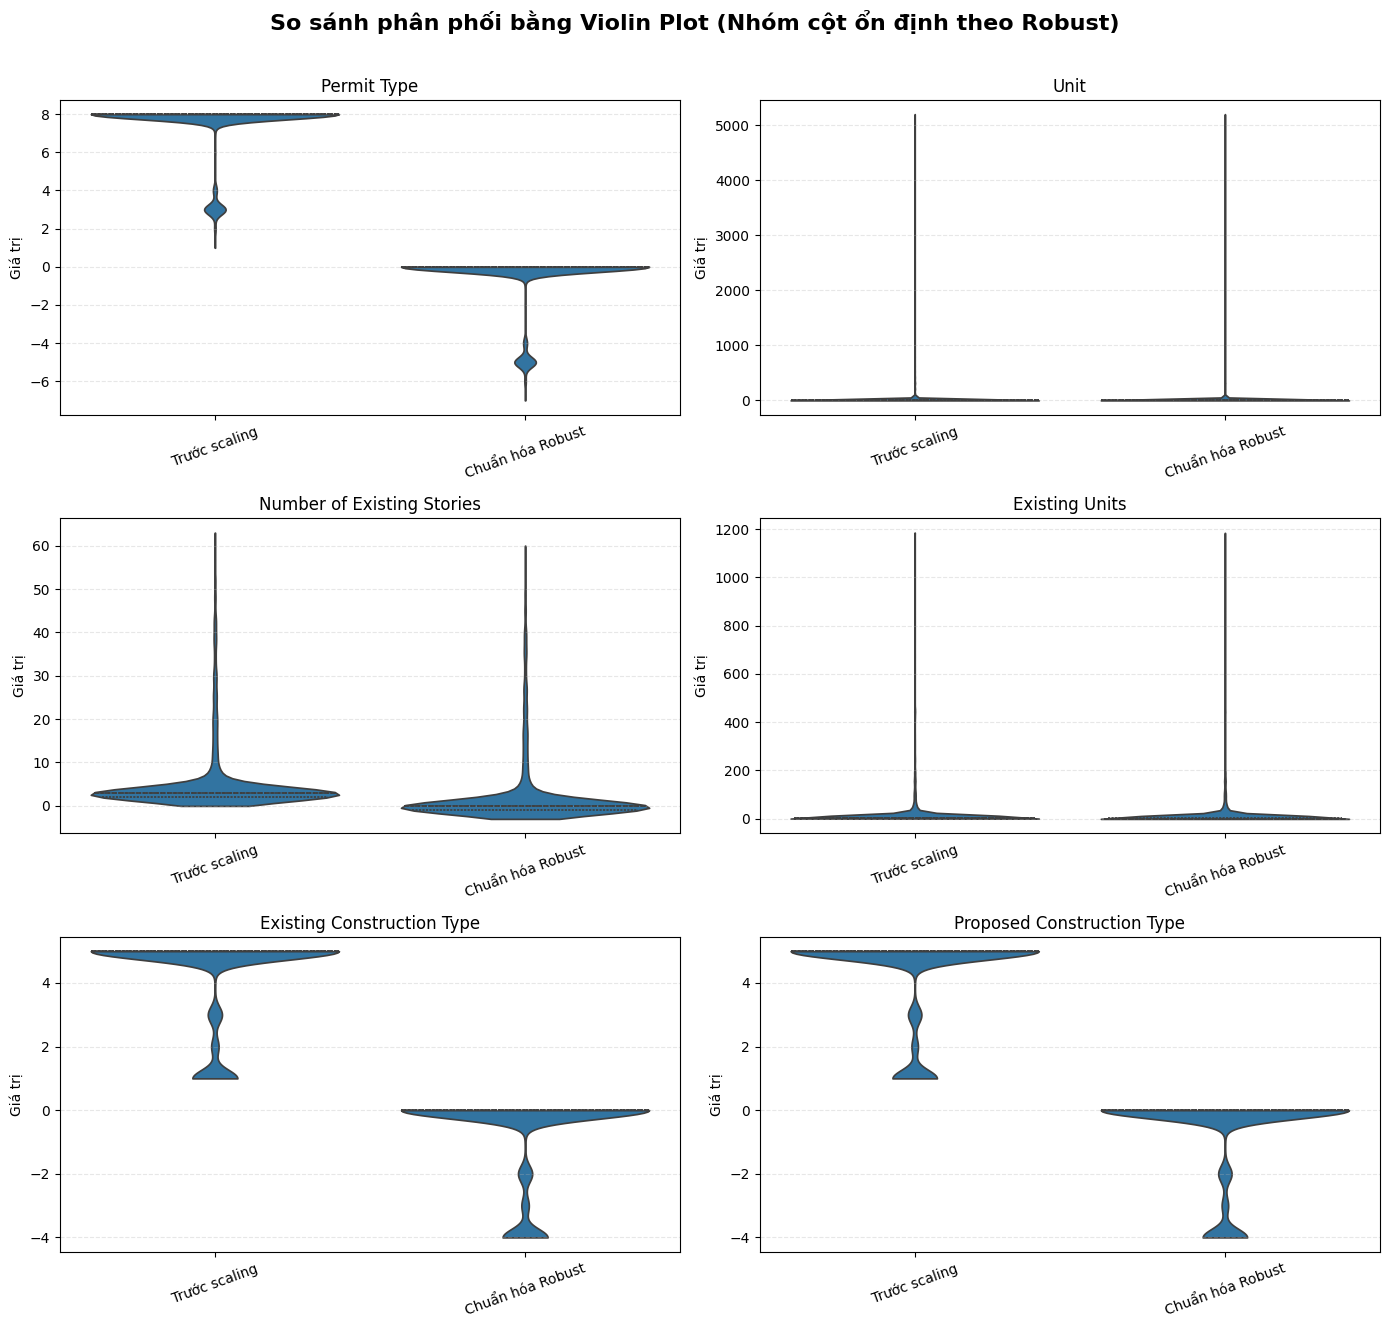

In [10]:
from visualization.distribution import plot_violin_comparison

# 1) Trực quan phân phối của toàn bộ cột số trước/sau các phương pháp scaling
plot_violin_comparison(
    before_df=X_numeric,
    after_dfs=scaled_results,
    columns=numeric_cols,
    sample_size=2500,
    ncols=3,
    title_suffix="(Building Permits - Trước/Sau các phương pháp scaling)",
)

# 2) Trực quan riêng nhóm cột không bác bỏ H0 dưới Robust (nếu có)
robust_stable_cols = []
if "Chuẩn hóa Robust" in levene_by_column:
    robust_stable_cols = (
        levene_by_column["Chuẩn hóa Robust"]
        .loc[lambda d: d["Quyết định"] == "Chưa bác bỏ H0", "Cột"]
        .tolist()
    )

if robust_stable_cols:
    print("Các cột không bác bỏ H0 dưới Robust:", robust_stable_cols)
    plot_violin_comparison(
        before_df=X_numeric,
        after_dfs={"Chuẩn hóa Robust": scaled_results["Chuẩn hóa Robust"]},
        columns=robust_stable_cols,
        sample_size=5000,
        ncols=2,
        title_suffix="(Nhóm cột ổn định theo Robust)",
    )
else:
    print("Không có cột nào thuộc nhóm Chưa bác bỏ H0 dưới Robust.")

<a id="sec-6-1"></a>

## 6.1 Nhận xét biểu đồ Violin Plot

- Nhóm cột biên độ lớn như **`Street Number`**, **`Estimated Cost`**, **`Revised Cost`**, **`Record ID`** có violin trước scaling rất dài; sau scaling thu gọn rõ rệt.
- **Min-Max** làm violin của nhiều cột bị nén vào miền hẹp, giảm mạnh độ phân tán trực quan.
- **Z-score** đưa nhiều violin về quanh tâm 0, hình cân đối hơn giữa các cột.
- **Quantile (uniform)** cho violin trải tương đối đều theo miền mới; **Quantile (normal)** làm nhiều violin gần dạng chuông hơn.
- Với **Robust**, một số cột có violin trước/sau chồng lấp mạnh (thay đổi ít), nổi bật là nhóm cột rời rạc và nhiều giá trị lặp.

Tóm lại, violin plot cho thấy bộ dữ liệu có phân phối rất không đồng nhất giữa các cột; mỗi phương pháp scaling tạo ra kiểu biến đổi phân phối khác nhau.